# SolarDrive — Dataset Characterisation (Sections III & IV)

Reproduces all dataset-level metrics and the annotation conversion step.

| Cell | What it produces | Paper reference |
|---|---|---|
| 1 | Mount Drive, unzip dataset | — |
| 2 | Install dependencies | — |
| 3 | **RIL computation** — per-sequence highlight & shadow fractions | **Table II** |
| 4 | **Dataset annotation statistics** — frames, boxes, density, class breakdown | **Table III** |
| 5 | **Glare severity classification** — per-image severity labels + distribution plot | Section III.F |
| 6 | **YOLO class distribution** — object counts per class + bar chart | Section III.F |
| 7 | **COCO-MOT format conversion** — YOLO labels → unified COCO JSON for MOTRv2 | Section IV.B |
| 8 | Save all outputs to Drive | — |

**Drive layout expected:**
```
MyDrive/
  SolarDrive_dataset.zip   ← images  (SolarDrive_dataset/images/<seq>/left_camera/)
  SolarDrive_labels.zip             ← labels  (SolarDrive_dataset/labels/<seq>/left_camera/)
  solardrive_figures/    ← output folder (created automatically)
```

**Run order:** Cells 1 → 6 in order. No GPU required.

---

## Cell 1 — Mount Drive & Unzip Dataset

Same setup as all other SolarDrive notebooks. Unzip is skipped if already done.

In [1]:
from google.colab import drive
import os, shutil, glob, subprocess

drive.mount('/content/drive')

# ── Edit these two paths if your zips are stored elsewhere in Drive ───────────
IMAGES_ZIP = '/content/drive/MyDrive/SolarDrive_dataset.zip'
LABELS_ZIP = '/content/drive/MyDrive/SolarDrive_labels.zip'
# ─────────────────────────────────────────────────────────────────────────────

DATASET   = '/content/SolarDrive_dataset'
DRIVE_OUT = '/content/drive/MyDrive/solardrive_figures'
SEQS      = ['sun_glare_0', 'sun_glare_1', 'sun_glare_2', 'sun_glare_3']

os.makedirs(DATASET,   exist_ok=True)
os.makedirs(DRIVE_OUT, exist_ok=True)

if not os.path.exists(f'{DATASET}/images'):
    print('Copying images zip ...')
    shutil.copy(IMAGES_ZIP, '/content/SolarDrive_dataset.zip')
    os.system('unzip -q /content/SolarDrive_dataset.zip -d /content/')
    # The zip may extract to a differently-named top-level folder — rename it
    result = subprocess.run(
        ['unzip', '-Z', '-1', '/content/SolarDrive_dataset.zip'],
        capture_output=True, text=True
    )
    top_folder = result.stdout.strip().split('\n')[0].split('/')[0]
    extracted = f'/content/{top_folder}'
    if top_folder and extracted != DATASET and os.path.exists(extracted):
        print(f'Renaming extracted folder: {top_folder} → SolarDrive_dataset')
        os.rename(extracted, DATASET)
    print('Images done.')
else:
    print('Images already unzipped — skipping.')

if not os.path.exists(f'{DATASET}/labels'):
    print('Copying labels zip ...')
    shutil.copy(LABELS_ZIP, '/content/SolarDrive_labels.zip')
    os.system(f'unzip -q /content/SolarDrive_labels.zip -d {DATASET}/')
    print('Labels done.')
else:
    print('Labels already unzipped — skipping.')

def find_dir(base, seq, kind):
    for path in [
        f'{base}/{kind}/{seq}/left_camera',
        f'{base}/{kind}/{seq}',
    ]:
        if os.path.isdir(path):
            return path
    return None

IMG_DIRS, LBL_DIRS = {}, {}
all_ok = True
print()
for seq in SEQS:
    img_dir = find_dir(DATASET, seq, 'images')
    lbl_dir = find_dir(DATASET, seq, 'labels')
    IMG_DIRS[seq] = img_dir
    LBL_DIRS[seq] = lbl_dir
    n_imgs = len(glob.glob(f'{img_dir}/*.*')) if img_dir else 0
    n_lbls = len(glob.glob(f'{lbl_dir}/*.txt')) if lbl_dir else 0
    ok = '✅' if img_dir and lbl_dir else '❌'
    print(f'  {ok} {seq}: {n_imgs} images  |  {n_lbls} label files')
    if not img_dir or not lbl_dir:
        all_ok = False

if not all_ok:
    raise RuntimeError('Some sequences missing — check IMAGES_ZIP / LABELS_ZIP paths.')
print('\n✅ Dataset ready.')

Mounted at /content/drive
Copying images zip ...
Renaming extracted folder: tartuglare_colab → SolarDrive_dataset
Images done.
Copying labels zip ...
Labels done.

  ✅ sun_glare_0: 836 images  |  836 label files
  ✅ sun_glare_1: 247 images  |  247 label files
  ✅ sun_glare_2: 323 images  |  323 label files
  ✅ sun_glare_3: 1046 images  |  1046 label files

✅ Dataset ready.


## Cell 2 — Install Dependencies

In [2]:
!pip install -q opencv-python-headless
import cv2, numpy as np
print('OpenCV :', cv2.__version__)
print('NumPy  :', np.__version__)

OpenCV : 4.13.0
NumPy  : 2.0.2


## Cell 3 — Radiometric Information Loss (RIL)

Computes the RIL metric for each sequence as defined in **Section III.E, Eq. (1)**:

$$\text{RIL} = \left(\frac{1}{H \times W} \sum_{i,j} \mathbb{1}(P_{ij} \leq 9 \;\vee\; P_{ij} \geq 245)\right) \times 100$$

Every frame is read as grayscale. Pixels are counted against two physical thresholds:

| Threshold | Physical meaning |
|---|---|
| ≤ 9 | Crushed shadows — SNR below usable floor, `∇I ≈ 0` |
| ≥ 245 | Blown highlights — photodiode saturation approaching full-well capacity |

These thresholds isolate the hardware bounds of the Sony IMX265 sensor
(72.7 dB dynamic range, 10,600e⁻ full-well capacity). See Section III.B.

In [3]:
import os
import cv2
import numpy as np

# Sensor-defined thresholds (Section III.B / III.E)
SHADOW_THRESH    = 9
HIGHLIGHT_THRESH = 245

ril_results = {}   # seq -> {highlight_pct, shadow_pct, total_ril, n_frames}

print('Computing RIL for all sequences ...')
print()
print(f'  {"Sequence":<14}  {"Frames":>7}  {"Highlight (≥245)":>17}  '
      f'{"Shadow (≤9)":>13}  {"Total RIL":>10}')
print('  ' + '-' * 68)

for seq in SEQS:
    folder = IMG_DIRS[seq]
    if not folder:
        print(f'  [SKIP] {seq}: image folder not found')
        continue

    images = [f for f in os.listdir(folder) if f.endswith(('.jpg', '.png'))]
    if not images:
        print(f'  [SKIP] {seq}: no images found')
        continue

    total_pixels     = 0
    total_highlights = 0
    total_shadows    = 0

    for img_name in images:
        # Grayscale read to evaluate raw pixel intensity
        img = cv2.imread(os.path.join(folder, img_name), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        total_pixels     += img.size
        total_highlights += int(np.sum(img >= HIGHLIGHT_THRESH))
        total_shadows    += int(np.sum(img <= SHADOW_THRESH))

    if total_pixels > 0:
        highlight_pct = (total_highlights / total_pixels) * 100
        shadow_pct    = (total_shadows    / total_pixels) * 100
        total_ril     = highlight_pct + shadow_pct

        ril_results[seq] = {
            'n_frames'     : len(images),
            'highlight_pct': round(highlight_pct, 2),
            'shadow_pct'   : round(shadow_pct,    2),
            'total_ril'    : round(total_ril,      2),
        }
        print(f'  {seq:<14}  {len(images):>7}  '
              f'{highlight_pct:>15.2f}%  '
              f'{shadow_pct:>11.2f}%  '
              f'{total_ril:>9.2f}%')

# Dataset averages
if ril_results:
    # Simple (unweighted) mean — reported in paper Table II
    simple_hl  = np.mean([v['highlight_pct'] for v in ril_results.values()])
    simple_sh  = np.mean([v['shadow_pct']    for v in ril_results.values()])
    simple_ril = np.mean([v['total_ril']      for v in ril_results.values()])
    # Frame-weighted mean — longer sequences contribute proportionally
    total_w    = sum(v['n_frames'] for v in ril_results.values())
    wtd_hl  = sum(v['highlight_pct'] * v['n_frames'] for v in ril_results.values()) / total_w
    wtd_sh  = sum(v['shadow_pct']    * v['n_frames'] for v in ril_results.values()) / total_w
    wtd_ril = sum(v['total_ril']     * v['n_frames'] for v in ril_results.values()) / total_w
    print('  ' + '-' * 68)
    print(f'  {"Average":<14}  {"":>7}  {simple_hl:>15.2f}%  {simple_sh:>11.2f}%  {simple_ril:>9.2f}%')
    print(f'  {"Wtd Average":<14}  {"":>7}  {wtd_hl:>15.2f}%  {wtd_sh:>11.2f}%  {wtd_ril:>9.2f}%')
    print()
    # Store both so the save cell can write them
    ril_simple_avg = {'highlight_pct': round(simple_hl, 2),
                      'shadow_pct':    round(simple_sh, 2),
                      'total_ril':     round(simple_ril, 2)}
    ril_wtd_avg    = {'highlight_pct': round(wtd_hl, 2),
                      'shadow_pct':    round(wtd_sh, 2),
                      'total_ril':     round(wtd_ril, 2)}
    print('✅ RIL computation complete.')

Computing RIL for all sequences ...

  Sequence         Frames   Highlight (≥245)    Shadow (≤9)   Total RIL
  --------------------------------------------------------------------
  sun_glare_0         836            26.18%         2.41%      28.59%
  sun_glare_1         247            30.22%         0.64%      30.86%
  sun_glare_2         323            26.98%         0.76%      27.74%
  sun_glare_3        1046            35.22%         1.19%      36.41%
  --------------------------------------------------------------------
  Average                            29.65%         1.25%      30.90%
  Wtd Average                        30.55%         1.49%      32.04%

✅ RIL computation complete.


## Cell 4 — Dataset Annotation Statistics

Computes the annotation statistics reported in **Table III** (Section III.F):
- Frames and bounding boxes per sequence
- Average scene density (objects / frame)
- Class-level distribution with percentages

**Label format:** `class_id  track_id  cx  cy  w  h` (6-column, normalised).

In [4]:
import os
from collections import defaultdict

CLASS_NAMES = {
    0: 'Pedestrian',
    1: 'Cyclist',
    2: 'Car',
    3: 'Motorcycle',
    4: 'Bus',
    5: 'Truck',
}

total_frames        = 0
total_boxes         = 0
global_class_counts = defaultdict(int)
seq_stats           = {}   # seq -> {frames, boxes, density}

print('=' * 55)
print('TABLE III — ANNOTATION AND SCALE STATISTICS')
print('=' * 55)
print(f'  {"Sequence":<14}  {"Frames":>7}  {"Boxes":>8}  {"Density":>9}')
print('  ' + '-' * 45)

for seq in SEQS:
    lbl_dir = LBL_DIRS[seq]
    if not lbl_dir:
        print(f'  [SKIP] {seq}: label folder not found')
        continue

    txt_files     = [f for f in os.listdir(lbl_dir) if f.endswith('.txt')]
    folder_frames = len(txt_files)
    folder_boxes  = 0

    for txt in txt_files:
        with open(os.path.join(lbl_dir, txt), encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                if len(parts) >= 5:
                    global_class_counts[int(parts[0])] += 1
                    folder_boxes += 1

    total_frames += folder_frames
    total_boxes  += folder_boxes
    density       = (folder_boxes / folder_frames) if folder_frames > 0 else 0
    seq_stats[seq] = {'frames': folder_frames, 'boxes': folder_boxes, 'density': round(density, 2)}

    print(f'  {seq:<14}  {folder_frames:>7}  {folder_boxes:>8}  {density:>8.2f}')

avg_density = (total_boxes / total_frames) if total_frames > 0 else 0
print('  ' + '-' * 45)
print(f'  {"Total":<14}  {total_frames:>7}  {total_boxes:>8}  {avg_density:>8.2f}')

print()
print('Class distribution:')
print(f'  {"Class":<14}  {"Count":>8}  {"Percent":>9}')
print('  ' + '-' * 36)
for cid, count in sorted(global_class_counts.items()):
    name = CLASS_NAMES.get(cid, f'Class {cid}')
    pct  = (count / total_boxes * 100) if total_boxes > 0 else 0
    print(f'  {name:<14}  {count:>8}  {pct:>8.1f}%')

print()
print('✅ Annotation statistics complete.')

TABLE III — ANNOTATION AND SCALE STATISTICS
  Sequence         Frames     Boxes    Density
  ---------------------------------------------
  sun_glare_0         836      3668      4.39
  sun_glare_1         247      1699      6.88
  sun_glare_2         323      1035      3.20
  sun_glare_3        1046      4194      4.01
  ---------------------------------------------
  Total              2452     10596      4.32

Class distribution:
  Class              Count    Percent
  ------------------------------------
  Pedestrian           245       2.3%
  Cyclist               27       0.3%
  Car                 9093      85.8%
  Motorcycle             1       0.0%
  Bus                  676       6.4%
  Truck                554       5.2%

✅ Annotation statistics complete.


## Cell 5 — Glare Severity Classification

Classifies every frame in each sequence into **severe / moderate / clear** based on
pixel saturation thresholds, and plots the distribution across the dataset.

**Classification logic (from `02_analyze_glare.py`):**
- `severe`   — global saturation > 15% **or** upper-region saturation > 25%
- `moderate` — global saturation > 5%  **or** upper-region saturation > 10%
- `clear`    — below both moderate thresholds

The upper region is defined as the top 35% of the frame height,
where sky and horizon glare typically appear.

**Paper reference:** Section III.F — dataset comprises 2,133 severe, 209 moderate,
and 110 clear frames.

Classifying frames by glare severity ...
  Sequence          Severe    Moderate    Clear    Total
  ----------------------------------------------------
  sun_glare_0          652         124       60      836
  sun_glare_1          219          18       10      247
  sun_glare_2          272          46        5      323
  sun_glare_3          990          21       35     1046
  ----------------------------------------------------
  Total               2133         209      110     2452
  Proportions:   87.0% severe  8.5% moderate  4.5% clear

✅ Saved: /content/drive/MyDrive/solardrive_figures/glare_severity_distribution.png


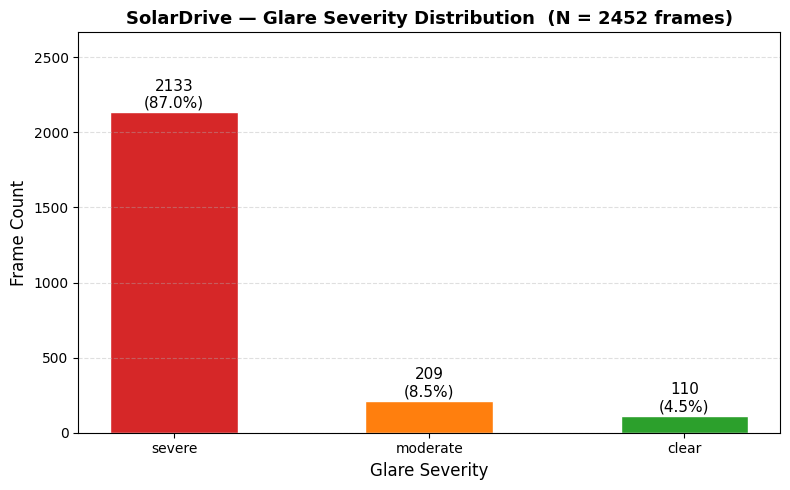

In [5]:
import os, cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ── Saturation thresholds (Section III.F) ─────────────────────────────────────
GLOBAL_SEVERE   = 0.15   # fraction of all pixels above 250
GLOBAL_MODERATE = 0.05
UPPER_SEVERE    = 0.25   # fraction of top-35% pixels above 250
UPPER_MODERATE  = 0.10
UPPER_FRAC      = 0.35   # top 35% of frame height = sky / horizon zone


def classify_frame(img_path):
    """Return severity label and saturation metrics for one frame."""
    img = cv2.imread(img_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    sat_global = np.sum(gray > 250) / gray.size
    upper_h    = int(h * UPPER_FRAC)
    sat_upper  = np.sum(gray[:upper_h, :] > 250) / (upper_h * w)

    if sat_global > GLOBAL_SEVERE or sat_upper > UPPER_SEVERE:
        severity = 'severe'
    elif sat_global > GLOBAL_MODERATE or sat_upper > UPPER_MODERATE:
        severity = 'moderate'
    else:
        severity = 'clear'

    return {
        'severity':         severity,
        'saturation_global': round(float(sat_global), 4),
        'saturation_upper':  round(float(sat_upper),  4),
    }


severity_counts = defaultdict(int)   # 'severe' / 'moderate' / 'clear'
seq_severity    = {}                  # seq -> counts dict

print('Classifying frames by glare severity ...')
print(f'  {"Sequence":<14}  {"Severe":>8}  {"Moderate":>10}  {"Clear":>7}  {"Total":>7}')
print('  ' + '-' * 52)

for seq in SEQS:
    img_dir = IMG_DIRS.get(seq)
    if not img_dir or not os.path.isdir(img_dir):
        print(f'  [SKIP] {seq}: image folder not found')
        continue

    frames = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))]
    counts = defaultdict(int)

    for fname in frames:
        result = classify_frame(os.path.join(img_dir, fname))
        if result:
            counts[result['severity']] += 1
            severity_counts[result['severity']] += 1

    seq_severity[seq] = dict(counts)
    total = sum(counts.values())
    print(f'  {seq:<14}  {counts["severe"]:>8}  {counts["moderate"]:>10}  '
          f'{counts["clear"]:>7}  {total:>7}')

# Dataset totals
total_all = sum(severity_counts.values())
print('  ' + '-' * 52)
print(f'  {"Total":<14}  {severity_counts["severe"]:>8}  '
      f'{severity_counts["moderate"]:>10}  {severity_counts["clear"]:>7}  {total_all:>7}')
print(f'  Proportions:   '
      f'{severity_counts["severe"]/total_all*100:.1f}% severe  '
      f'{severity_counts["moderate"]/total_all*100:.1f}% moderate  '
      f'{severity_counts["clear"]/total_all*100:.1f}% clear')

# ── Distribution bar chart ────────────────────────────────────────────────────
labels  = ['severe', 'moderate', 'clear']
colors  = ['#d62728', '#ff7f0e', '#2ca02c']
values  = [severity_counts[l] for l in labels]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f'{val}\n({val/total_all*100:.1f}%)',
            ha='center', va='bottom', fontsize=11)
ax.set_title(f'SolarDrive — Glare Severity Distribution  (N = {total_all} frames)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Glare Severity', fontsize=12)
ax.set_ylabel('Frame Count', fontsize=12)
ax.set_ylim(0, max(values) * 1.25)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

OUT = f'{DRIVE_OUT}/glare_severity_distribution.png'
plt.savefig(OUT, dpi=300)
print(f'\n✅ Saved: {OUT}')
plt.show()


## Cell 6 — YOLO Class Distribution

Scans all label files recursively, counts annotations per class, and produces
a bar chart of the object distribution across the full dataset.

**Label format:** `class_id  track_id  cx  cy  w  h` (6-column, normalised).
The first column is the class ID — all other columns are ignored here.

**Paper reference:** Section III.F — class distribution (Car 85.8%, Bus 6.4%, etc.).

Scanning label files for class distribution ...

 CLASS DISTRIBUTION (YOLO FORMAT)
  Label files scanned : 2452
  Empty files         : 188
  Total objects       : 10,596

  Class              Count    Percent
  ------------------------------------
  Car                 9093      85.8%
  Bus                  676       6.4%
  Truck                554       5.2%
  Pedestrian           245       2.3%
  Cyclist               27       0.3%
  Motorcycle             1       0.0%

✅ Saved: /content/drive/MyDrive/solardrive_figures/class_distribution.png


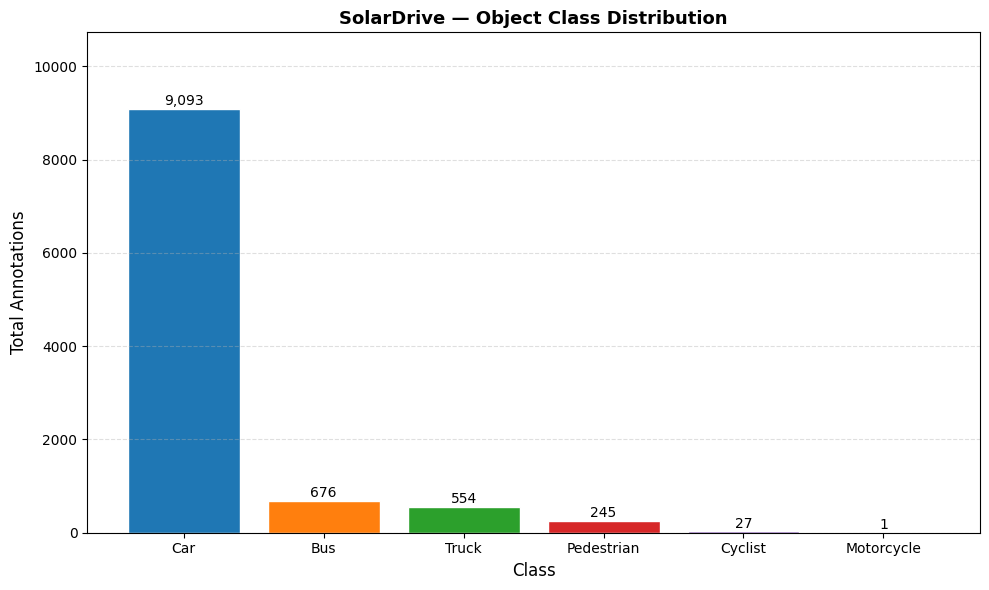

In [6]:
import os
import matplotlib.pyplot as plt
from collections import defaultdict

CLASS_NAMES_DIST = {
    0: 'Pedestrian',
    1: 'Cyclist',
    2: 'Car',
    3: 'Motorcycle',
    4: 'Bus',
    5: 'Truck',
}

dist_counts = defaultdict(int)
file_count  = 0
empty_count = 0

print('Scanning label files for class distribution ...')

for seq in SEQS:
    lbl_dir = LBL_DIRS.get(seq)
    if not lbl_dir or not os.path.isdir(lbl_dir):
        print(f'  [SKIP] {seq}: label folder not found')
        continue
    txt_files = [f for f in os.listdir(lbl_dir) if f.endswith('.txt')]
    for txt in txt_files:
        file_count += 1
        lines = []
        with open(os.path.join(lbl_dir, txt), encoding='utf-8') as f:
            lines = [l.strip() for l in f if l.strip()]
        if not lines:
            empty_count += 1
            continue
        for line in lines:
            parts = line.split()
            if len(parts) >= 1:
                dist_counts[int(parts[0])] += 1

total_obj = sum(dist_counts.values())

# ── Text report ───────────────────────────────────────────────────────────────
print()
print('=' * 55)
print(' CLASS DISTRIBUTION (YOLO FORMAT)')
print('=' * 55)
print(f'  Label files scanned : {file_count}')
print(f'  Empty files         : {empty_count}')
print(f'  Total objects       : {total_obj:,}')
print()
print(f'  {"Class":<14}  {"Count":>8}  {"Percent":>9}')
print('  ' + '-' * 36)
# Sort by count descending
for cid, count in sorted(dist_counts.items(), key=lambda x: -x[1]):
    name = CLASS_NAMES_DIST.get(cid, f'Class {cid}')
    pct  = (count / total_obj * 100) if total_obj > 0 else 0
    print(f'  {name:<14}  {count:>8}  {pct:>8.1f}%')

# ── Bar chart ─────────────────────────────────────────────────────────────────
# Order: most common first
sorted_items = sorted(dist_counts.items(), key=lambda x: -x[1])
class_labels = [CLASS_NAMES_DIST.get(cid, f'Class {cid}') for cid, _ in sorted_items]
class_values = [count for _, count in sorted_items]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(class_labels, class_values,
              color=['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b'],
              edgecolor='white')
for bar, val in zip(bars, class_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f'{val:,}', ha='center', va='bottom', fontsize=10)
ax.set_title('SolarDrive — Object Class Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Total Annotations', fontsize=12)
ax.set_ylim(0, max(class_values) * 1.18)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

OUT = f'{DRIVE_OUT}/class_distribution.png'
plt.savefig(OUT, dpi=300)
print(f'\n✅ Saved: {OUT}')
plt.show()


## Cell 7 — COCO-MOT Format Conversion

Converts the YOLO-format label files into a single COCO-MOT JSON file
(`tartuglare_mot_coco.json`) required by **MOTRv2** and similar
transformer-based end-to-end trackers.

**Input label format** (per line): `class_id  track_id  x_c  y_c  w  h`  
All coordinates are normalised (0–1) relative to image dimensions.

**Output:** COCO-MOT JSON with `images`, `annotations`, `categories`, `videos`.
Bounding boxes are converted to absolute pixel coordinates in  
COCO format `[x_min, y_min, width, height]`.

**Paper reference:** Section IV.B — Annotation Policy and MOT Conversion.

In [7]:
import os
import cv2
import json

OUTPUT_JSON = f'{DRIVE_OUT}/tartuglare_mot_coco.json'

# Category definitions — 6 TartuGlare classes (Section IV.A.3)
# COCO standard: category IDs must start at 1 (not 0).
# TartuGlare class 0→1, 1→2, ..., 5→6
CATEGORIES = [
    {'id': 1, 'name': 'Pedestrian'},
    {'id': 2, 'name': 'Cyclist'},
    {'id': 3, 'name': 'Car'},
    {'id': 4, 'name': 'Motorcycle'},
    {'id': 5, 'name': 'Bus'},
    {'id': 6, 'name': 'Truck'},
]

coco_data = {
    'images'     : [],
    'annotations': [],
    'categories' : CATEGORIES,
    'videos'     : [],
}

annotation_id = 1
image_id      = 1
video_id      = 1

for seq in SEQS:
    img_dir = IMG_DIRS[seq]
    lbl_dir = LBL_DIRS[seq]

    if not img_dir:
        print(f'[SKIP] {seq}: image folder not found')
        video_id += 1
        continue

    coco_data['videos'].append({'id': video_id, 'name': seq})

    img_files = sorted(
        f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))
    )
    img_h, img_w = None, None

    for frame_idx, img_name in enumerate(img_files):
        # Read dimensions once from the first frame (constant per sequence)
        if frame_idx == 0:
            sample = cv2.imread(os.path.join(img_dir, img_name))
            if sample is None:
                raise RuntimeError(f'Could not read: {img_name}')
            img_h, img_w = sample.shape[:2]

        coco_data['images'].append({
            'id'       : image_id,
            'video_id' : video_id,
            'frame_id' : frame_idx + 1,   # 1-indexed (MOT convention)
            'file_name': f'{seq}/left_camera/{img_name}',
            'height'   : img_h,
            'width'    : img_w,
        })

        # Parse corresponding YOLO label file
        if lbl_dir:
            lbl_path = os.path.join(lbl_dir, img_name.rsplit('.', 1)[0] + '.txt')
            if os.path.exists(lbl_path):
                with open(lbl_path) as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) < 6:
                            continue
                        cls_id   = int(parts[0])
                        track_id = int(parts[1])
                        x_c, y_c, w, h = map(float, parts[2:6])

                        # Normalised YOLO [x_c, y_c, w, h] → absolute COCO [x_min, y_min, w, h]
                        abs_w = w   * img_w
                        abs_h = h   * img_h
                        abs_x = x_c * img_w - abs_w / 2
                        abs_y = y_c * img_h - abs_h / 2
                        # Clamp to image bounds (mirrors tracking notebooks)
                        abs_x = max(0.0, abs_x)
                        abs_y = max(0.0, abs_y)
                        abs_w = min(abs_w, img_w - abs_x)
                        abs_h = min(abs_h, img_h - abs_y)
                        if abs_w <= 0 or abs_h <= 0:
                            continue

                        coco_data['annotations'].append({
                            'id'         : annotation_id,
                            'image_id'   : image_id,
                            'category_id': cls_id + 1,  # COCO IDs are 1-indexed
                            'track_id'   : track_id,
                            'bbox'       : [abs_x, abs_y, abs_w, abs_h],
                            'area'       : abs_w * abs_h,
                            'iscrowd'    : 0,
                        })
                        annotation_id += 1

        image_id += 1

    print(f'  ✅ {seq}: {len(img_files)} frames  |  video_id={video_id}')
    video_id += 1

# Save JSON
print(f'\nSaving COCO-MOT JSON ({len(coco_data["images"]):,} images, '
      f'{len(coco_data["annotations"]):,} annotations) ...')
with open(OUTPUT_JSON, 'w') as f:
    json.dump(coco_data, f)

print(f'✅ Saved: {OUTPUT_JSON}')
print(f'   File size: {os.path.getsize(OUTPUT_JSON)/1e6:.1f} MB')

  ✅ sun_glare_0: 836 frames  |  video_id=1
  ✅ sun_glare_1: 247 frames  |  video_id=2
  ✅ sun_glare_2: 323 frames  |  video_id=3
  ✅ sun_glare_3: 1046 frames  |  video_id=4

Saving COCO-MOT JSON (2,452 images, 10,596 annotations) ...
✅ Saved: /content/drive/MyDrive/solardrive_figures/tartuglare_mot_coco.json
   File size: 2.2 MB


## Cell 8 — Save Text Summaries to Drive

In [8]:
import json, os, numpy as np

# ── RIL results text ──────────────────────────────────────────────────────────
ril_txt = f'{DRIVE_OUT}/RIL_results.txt'
with open(ril_txt, 'w', encoding='utf-8') as f:
    f.write('=' * 60 + '\n')
    f.write('  SOLARDRIVE — RADIOMETRIC INFORMATION LOSS (RIL)\n')
    f.write('  Thresholds: shadow ≤ 9,  highlight ≥ 245\n')
    f.write('=' * 60 + '\n\n')
    f.write(f'  {"Sequence":<14}  {"Frames":>7}  {"Highlight":>10}  '
            f'{"Shadow":>8}  {"Total RIL":>10}\n')
    f.write('  ' + '-' * 55 + '\n')
    for seq, r in ril_results.items():
        f.write(f'  {seq:<14}  {r["n_frames"]:>7}  '
                f'{r["highlight_pct"]:>9.2f}%  '
                f'{r["shadow_pct"]:>7.2f}%  '
                f'{r["total_ril"]:>9.2f}%\n')
    total_w  = sum(v['n_frames'] for v in ril_results.values())
    avg_hl_w = sum(v['highlight_pct'] * v['n_frames'] for v in ril_results.values()) / total_w
    avg_sh_w = sum(v['shadow_pct']    * v['n_frames'] for v in ril_results.values()) / total_w
    avg_ril  = sum(v['total_ril']     * v['n_frames'] for v in ril_results.values()) / total_w
    f.write('  ' + '-' * 55 + '\n')
    f.write(f'  {"Weighted Avg":<14}  {"":>7}  '
            f'{avg_hl_w:>9.2f}%  '
            f'{avg_sh_w:>7.2f}%  '
            f'{avg_ril:>9.2f}%\n')
print(f'✅ RIL results saved: {ril_txt}')

# ── Annotation statistics text ────────────────────────────────────────────────
stats_txt = f'{DRIVE_OUT}/dataset_statistics.txt'
with open(stats_txt, 'w', encoding='utf-8') as f:
    f.write('=' * 55 + '\n')
    f.write('  SOLARDRIVE — ANNOTATION AND SCALE STATISTICS\n')
    f.write('=' * 55 + '\n\n')
    f.write(f'  {"Sequence":<14}  {"Frames":>7}  {"Boxes":>8}  {"Density":>9}\n')
    f.write('  ' + '-' * 45 + '\n')
    for seq, s in seq_stats.items():
        f.write(f'  {seq:<14}  {s["frames"]:>7}  {s["boxes"]:>8}  {s["density"]:>8.2f}\n')
    f.write('  ' + '-' * 45 + '\n')
    f.write(f'  {"Total":<14}  {total_frames:>7}  {total_boxes:>8}  {avg_density:>8.2f}\n')
    f.write('\nClass distribution:\n')
    for cid, count in sorted(global_class_counts.items()):
        name = CLASS_NAMES.get(cid, f'Class {cid}')
        pct  = (count / total_boxes * 100) if total_boxes > 0 else 0
        f.write(f'  {name:<14}  {count:>8}  ({pct:.1f}%)\n')
print(f'✅ Dataset statistics saved: {stats_txt}')

# ── List all saved outputs ────────────────────────────────────────────────────
import glob as gb
print()
print(f'All outputs in {DRIVE_OUT}/')
for fpath in sorted(gb.glob(f'{DRIVE_OUT}/*')):
    size = os.path.getsize(fpath) / 1024
    print(f'  {os.path.basename(fpath):<50}  {size:>8.1f} KB')

✅ RIL results saved: /content/drive/MyDrive/solardrive_figures/RIL_results.txt
✅ Dataset statistics saved: /content/drive/MyDrive/solardrive_figures/dataset_statistics.txt

All outputs in /content/drive/MyDrive/solardrive_figures/
  RIL_results.txt                                          0.7 KB
  class_distribution.png                                 112.6 KB
  dataset_statistics.txt                                   0.7 KB
  figure1_comparison_matrix.png                          285.6 KB
  figure1_geographical_map.html                           18.3 KB
  figure1_map.html                                        20.9 KB
  figure2_dataset_diversity.png                        13187.8 KB
  figure2_map.html                                        17.4 KB
  figure3_dataset_diversity.png                        13168.2 KB
  figure3_histograms.png                                 326.1 KB
  figure3_intensity_histograms.png                       328.7 KB
  figure4_confidence_vs_brightness.png     